In [30]:

# %pip install tensorflow[and-cuda]
# %pip install keras
# %pip install tensorboard
# %pip install matplotlib
# %pip install scikit-learn

In [31]:
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')
import logging
logger = tf.get_logger()
logger.setLevel(logging.ERROR) 
import keras
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict
import uuid
import datetime


In [32]:
#%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [33]:
# Clear any logs from previous runs
!rm -rf ./logs/ 

In [34]:
# Load the TensorBoard notebook extension
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [35]:
print('Using:')
print('\t\u2022 TensorFlow version:', tf.__version__)
print('\t\u2022 tf.keras version:', keras.__version__)
# print('\t\u2022 Running on GPU' if tf.test.is_gpu_available() else '\t\u2022 GPU device not found. Running on CPU')

Using:
	• TensorFlow version: 2.19.0
	• tf.keras version: 3.10.0


In [36]:
# Model Config

VOCAB_SIZE: int = 128
MAX_LENGTH: int = 100
MODEL_DIMENSION: int = 128
NUM_HEADS: int = 8
NUM_LAYERS: int = 4
FF_DIM: int = 512
DROPOUT_RATE: float = 0.1

CLASS_NAMES = {
    0: 'int',
    1: 'float',
    2: 'boolean',
    3: 'date',
    4: 'datetime',
    5: 'uuid',
    6: 'string'
}

In [37]:
def preprocess_string(input: str) -> np.ndarray:
    encoded = [ord(c) % VOCAB_SIZE for c in input[:MAX_LENGTH].upper()]
    if len(encoded) < MAX_LENGTH:
        encoded.extend([0] * (MAX_LENGTH - len(encoded)))
    
    return np.array(encoded)

In [38]:
class TypeInferenceTransformer:
    """
    Transformer-based neural network for inferring data types from string representations
    """
    def __init__(
        self, 
        class_names: Dict,
        vocab_size: int = VOCAB_SIZE,
        max_length: int = MAX_LENGTH,
        model_dimension: int = MODEL_DIMENSION,
        num_heads: int = NUM_HEADS,
        num_layers: int = NUM_LAYERS,
        ff_dim: int = FF_DIM,
        dropout_rate: float = DROPOUT_RATE
        ):
        """
        Initialize the type inference transformer.
        
        Args:
            vocab_size: Size of vocabulary (default: ASCII)
            max_length: Maximum string length
            d_model: Dimension of the model
            num_heads: Number of attention heads
            num_layers: Number of transformer layers
            ff_dim: Feed-forward dimension
            dropout_rate: Dropout rate
        """
        self.__vocab_size = vocab_size
        self.__max_length = max_length
        self.__d_model = model_dimension
        self.__num_heads = num_heads
        self.__num_layers = num_layers
        self.__ff_dim = ff_dim
        self.__dropout_rate = dropout_rate
        
        self.__type_mapping = class_names
        # num_classes: Number of type classes to predict
        self.__num_classes = len(self.__type_mapping)
        
        self.__model = self.__build_model()
        
    def __build_model(self) -> tf.keras.Model:
        """Build the transformer model."""
        # Input layer
        inputs = tf.keras.layers.Input(shape=(self.__max_length,))
        
        # Embedding layer
        embedding = tf.keras.layers.Embedding(
            input_dim=self.__vocab_size,
            output_dim=self.__d_model
        )(inputs)
        
        # Positional encoding
        positions = tf.range(start=0, limit=self.__max_length, delta=1)
        position_embedding = tf.keras.layers.Embedding(
            input_dim=self.__max_length,
            output_dim=self.__d_model
        )(positions)
        
        # Combine embeddings
        x = embedding + position_embedding
        
        # Transformer encoder layers
        for _ in range(self.__num_layers):
            x = self.__transformer_encoder_layer(x)
        
        # Global average pooling
        x = tf.keras.layers.GlobalAveragePooling1D()(x)
        
        # Classification head
        x = tf.keras.layers.Dense(256, activation='relu')(x)
        x = tf.keras.layers.Dropout(self.__dropout_rate)(x)
        x = tf.keras.layers.Dense(128, activation='relu')(x)
        x = tf.keras.layers.Dropout(self.__dropout_rate)(x)
        outputs = tf.keras.layers.Dense(self.__num_classes, activation='softmax')(x)
        
        model = tf.keras.Model(inputs=inputs, outputs=outputs)
        return model
    
    def __transformer_encoder_layer(self, x: tf.Tensor) -> tf.Tensor:
        """Single transformer encoder layer."""
        # Multi-head self-attention
        attn_output = tf.keras.layers.MultiHeadAttention(
            num_heads=self.__num_heads,
            key_dim=self.__d_model // self.__num_heads,
            dropout=self.__dropout_rate
        )(x, x)
        
        # Dropout and residual connection
        attn_output = tf.keras.layers.Dropout(self.__dropout_rate)(attn_output)
        x1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
        
        # Feed-forward network
        ff_output = tf.keras.Sequential([
            tf.keras.layers.Dense(self.__ff_dim, activation='relu'),
            tf.keras.layers.Dropout(self.__dropout_rate),
            tf.keras.layers.Dense(self.__d_model)
        ])(x1)
        
        # Dropout and residual connection
        ff_output = tf.keras.layers.Dropout(self.__dropout_rate)(ff_output)
        x2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x1 + ff_output)
        
        return x2
    
    def summary(self):
        return self.__model.summary()
    
    def __compile_model(self, learning_rate: float):
        self.__model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
    
    def fit(
            self, 
            X_train, 
            y_train,
            batch_size: int,
            epochs: int,
            learning_rate: float,
        ):
        
        model.__compile_model(learning_rate=learning_rate)
        
        current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
        tensorboard_log_dir = f"./logs/fit/{current_time}"
        
        history = self.__model.fit(
            X_train, 
            y_train,
            validation_split=0.2,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[
                tf.keras.callbacks.EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True),
                tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5),
                tf.keras.callbacks.ModelCheckpoint('./best_model/best_model_{}.keras'.format(current_time), monitor='val_loss', save_best_only=True),
                tf.keras.callbacks.TensorBoard(log_dir=tensorboard_log_dir, histogram_freq=1)
            ]
        )
        
        return history
    
    def evaluate(self, test_batches):
        return self.__model.evaluate(test_batches)
    
    def predict(self, string: str) -> Dict[str, float]:
        x = preprocess_string(string)
        x = np.expand_dims(x, axis=0)
        
        predictions = self.__model.predict(x, verbose=0)[0]
        
        results = {}
        for i, prob in enumerate(predictions):
            results[self.__type_mapping[i]] = float(prob)
        
        return results
    
    def predict_type(self, string: str) -> str:
        predictions = self.predict(string)
        return max(predictions, key=predictions.get)

In [39]:
def generate_synthetic_data(samples_per_type: int = 1000) -> Tuple[np.ndarray, np.ndarray]:
    """Generate synthetic training data."""
    X = []
    y = []
    
    # Integer patterns
    for _ in range(samples_per_type):
        val = str(np.random.randint(-10000, 10000))
        X.append(val)
        y.append(0)
    
    # Float patterns
    for _ in range(samples_per_type):
        val = f"{np.random.uniform(-1000, 1000):.{np.random.randint(1, 6)}f}"
        X.append(val)
        y.append(1)
    
    # Boolean patterns
    boolean_values = ['TRUE', 'FALSE', '1', '0', 'YES', 'NO']
    for _ in range(samples_per_type):
        val = np.random.choice(boolean_values)
        X.append(val)
        y.append(2)
    
    # Date patterns
    for _ in range(samples_per_type):
        year = np.random.randint(1900, 2030)
        month = np.random.randint(1, 13)
        day = np.random.randint(1, 29)
        formats = [f"{year}-{month:02d}-{day:02d}", 
                  f"{month:02d}/{day:02d}/{year}",
                  f"{day:02d}-{month:02d}-{year}"]
        val = np.random.choice(formats)
        X.append(val)
        y.append(3)
    
    # DateTime patterns
    for _ in range(samples_per_type):
        year = np.random.randint(1900, 2030)
        month = np.random.randint(1, 13)
        day = np.random.randint(1, 29)
        hour = np.random.randint(0, 24)
        minute = np.random.randint(0, 60)
        val = f"{year}-{month:02d}-{day:02d} {hour:02d}:{minute:02d}"
        X.append(val)
        y.append(4)
    
    # UUID patterns
    for _ in range(samples_per_type):
        val = str(uuid.uuid4())
        X.append(val)
        y.append(5)
    
    # General string patterns
    for _ in range(samples_per_type):
        length = np.random.randint(5, 30)
        val = ''.join(np.random.choice(list('ABCDEFGHIJKLMNOPQRSTUVWXYZ '), size=length))
        X.append(val)
        y.append(6)
    
    return np.array(X), np.array(y)

In [40]:
model = TypeInferenceTransformer(class_names=CLASS_NAMES)
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 100, 128)  │     16,384 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 100, 128)  │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 100, 128)  │     66,048 │ add_9[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_9[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 100, 128)  │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 100, 128)  │          0 │ add_9[0][0],      │
│                     │                   │            │ dropout_19[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 128)  │        256 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 100, 128)  │    131,712 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 100, 128)  │          0 │ sequential_4[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 100, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_21[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 128)  │        256 │ add_11[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 100, 128)  │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 100, 128)  │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 100, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_23[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 128)  │        256 │ add_12[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_5        │ (None, 100, 128)  │    131,712 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 100, 128)  │          0 │ sequential_5[0][… │
│ (Dropout)           │                   │            │                 

 Total params: 876,295 (3.34 MB)

 Trainable params: 876,295 (3.34 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
BATCH_SIZE: int = 32
EPOCHS: int = 20
LEARNING_RATE: float = 0.001

In [42]:
    
NUM_TRAINING_EXAMPLES: int = 1000
NUM_VALIDATION_EXAMPLES: int = 200
NUM_TEST_EXAMPLES: int = 200

In [43]:
X_train, y_train = generate_synthetic_data(samples_per_type=NUM_TRAINING_EXAMPLES)
X_train = np.array([preprocess_string(s) for s in X_train])
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
training_batches = train_dataset.shuffle(NUM_TRAINING_EXAMPLES//4).batch(BATCH_SIZE).prefetch(1) 

In [44]:
X_validation, y_validation = generate_synthetic_data(samples_per_type=NUM_VALIDATION_EXAMPLES)  
X_validation = np.array([preprocess_string(s) for s in X_validation])
validation_dataset = tf.data.Dataset.from_tensor_slices((X_validation, y_validation))
validation_batches = validation_dataset.batch(BATCH_SIZE).prefetch(1)

In [45]:
X_test, y_test = generate_synthetic_data(samples_per_type=NUM_TEST_EXAMPLES)  
X_test = np.array([preprocess_string(s) for s in X_test])
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_batches = test_dataset.batch(BATCH_SIZE).prefetch(1)

In [46]:
indices = np.random.permutation(len(X_train))
X_train = X_train[indices]
y_train = y_train[indices]

In [47]:
#history = model.fit(training_batches, validation_batches, batch_size=BATCH_SIZE, epochs=EPOCHS, learning_rate=LEARNING_RATE)
history = model.fit(X_train, y_train, batch_size=BATCH_SIZE, epochs=EPOCHS, learning_rate=LEARNING_RATE)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.5154 - loss: 1.1981 - val_accuracy: 1.0000 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9762 - loss: 0.0906 - val_accuracy: 1.0000 - val_loss: 0.0135 - learning_rate: 0.0010
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9600 - loss: 0.1633 - val_accuracy: 0.9993 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9912 - loss: 0.0340 - val_accuracy: 0.9993 - val_loss: 0.0061 - learning_rate: 0.0010
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9992 - loss: 0.0047 - val_accuracy: 0.9993 - val_loss: 0.0085 - learning_rate: 5.0000e-04
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9979 - val_loss: 0.0158 - learning_rate: 5.0000e-04


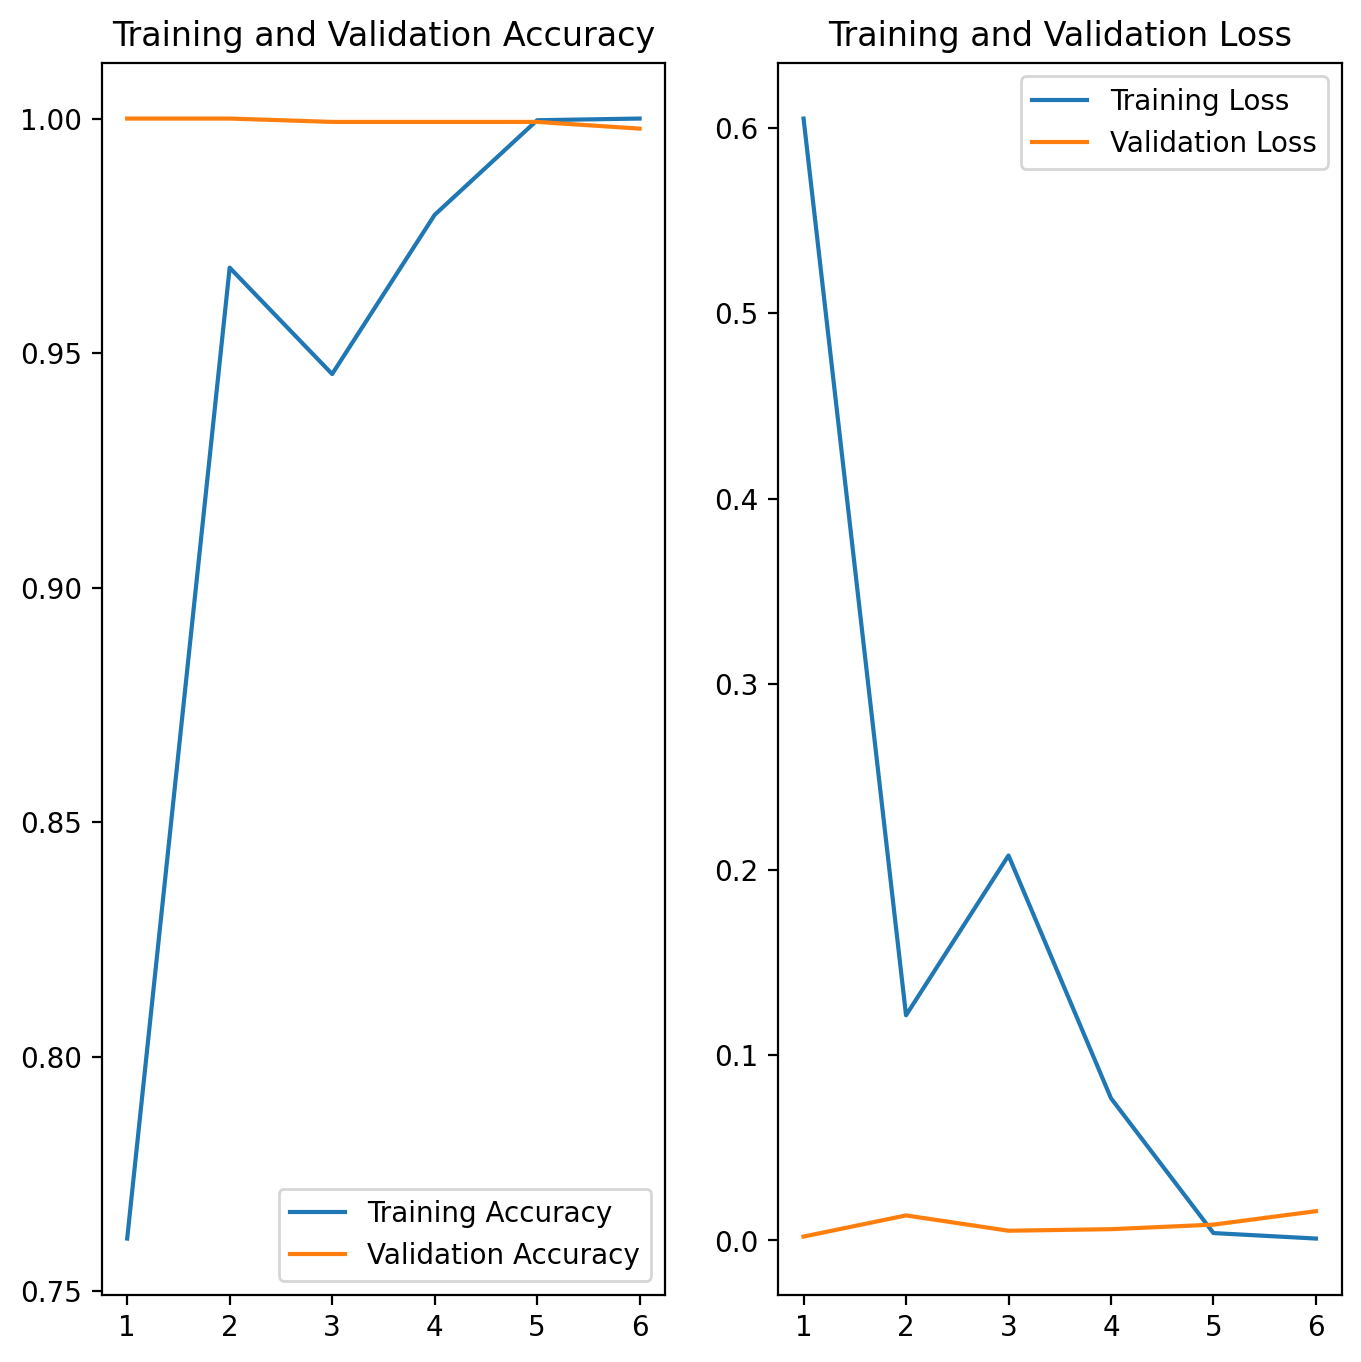

In [48]:
# Extract metrics from history
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']
epochs_range = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_accuracy, label='Training Accuracy')
plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_loss, label='Training Loss')
plt.plot(epochs_range, validation_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [49]:
%tensorboard --logdir logs/fit

Reusing TensorBoard on port 6006 (pid 255223), started 0:14:40 ago. (Use '!kill 255223' to kill it.)

In [50]:
loss, accuracy = model.evaluate(test_batches)
print('\nLoss on the TEST Set: {:,.3f}'.format(loss))
print('Accuracy on the TEST Set: {:.3%}'.format(accuracy))

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9999 - loss: 0.0023

Loss on the TEST Set: 0.003
Accuracy on the TEST Set: 99.929%


2025-06-06 03:16:56.885876: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


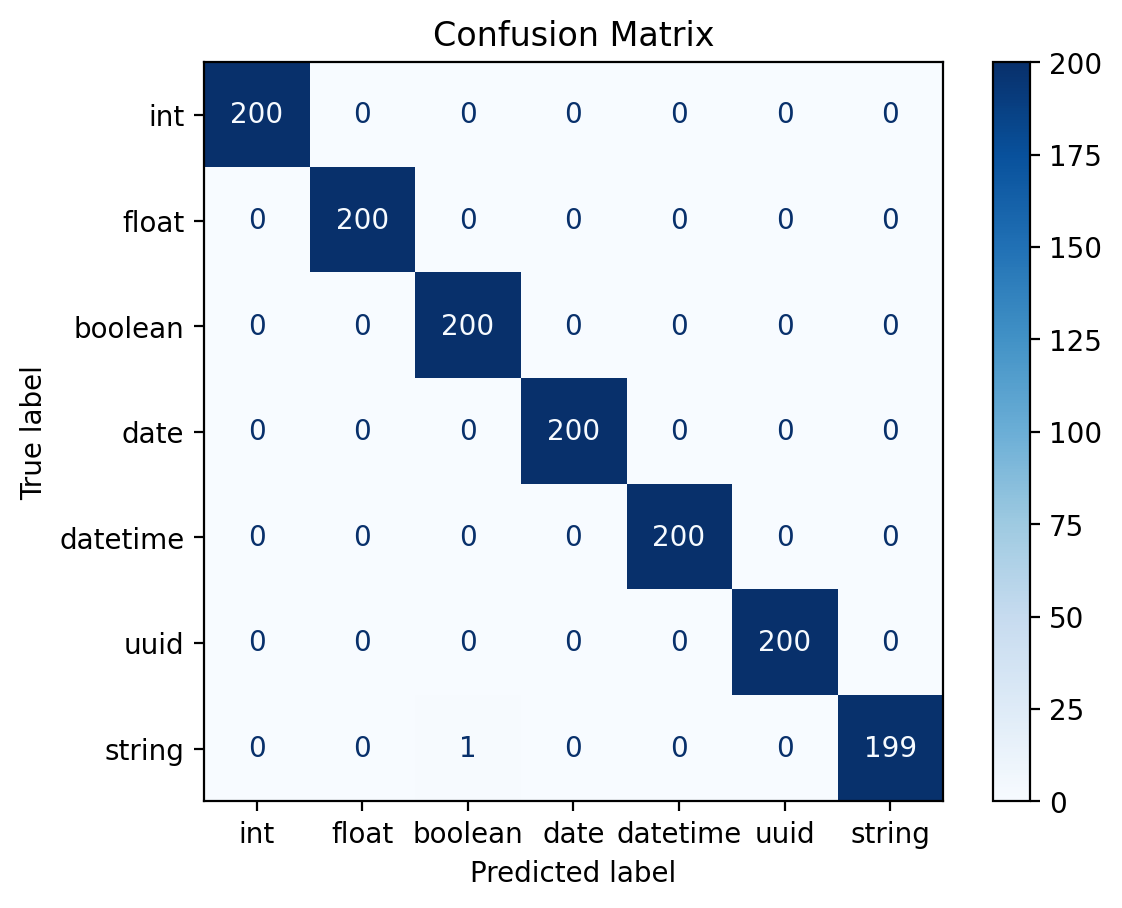

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get true labels and predictions from the test set
y_true = []
y_pred = []

for features, labels in test_batches:
    preds = model._TypeInferenceTransformer__model.predict(features, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES.values())
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


In [52]:
test_strings = [
        "42",
        "3.14159",
        "true",
        "2024-01-15",
        "2024-01-15 14:30:00",
        "user@example.com",
        "493729a5-88ef-43da-aa20-00daee032f77",
        "Hello, World!",
    ]
    
print("\nPredictions:")
print("-" * 50)
for test_str in test_strings:
    pred_type = model.predict_type(test_str)
    probs = model.predict(test_str)
    print(f"String: '{test_str}'")
    print(f"Predicted type: {pred_type}")
    print(f"Confidence: {probs[pred_type]:.2%}")
    print("-" * 50)


Predictions:
--------------------------------------------------
String: '42'
Predicted type: int
Confidence: 99.76%
--------------------------------------------------
String: '3.14159'
Predicted type: float
Confidence: 99.90%
--------------------------------------------------
String: 'true'
Predicted type: boolean
Confidence: 100.00%
--------------------------------------------------
String: '2024-01-15'
Predicted type: date
Confidence: 99.31%
--------------------------------------------------
String: '2024-01-15 14:30:00'
Predicted type: datetime
Confidence: 90.20%
--------------------------------------------------
String: 'user@example.com'
Predicted type: string
Confidence: 99.99%
--------------------------------------------------
String: '493729a5-88ef-43da-aa20-00daee032f77'
Predicted type: uuid
Confidence: 99.99%
--------------------------------------------------
String: 'Hello, World!'
Predicted type: string
Confidence: 99.98%
--------------------------------------------------
